# Kernel PCA

In [1]:
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
X.shape, t.shape

((1000, 3), (1000,))

In [2]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.04)
X_reduced = rbf_pca.fit_transform(X)
X_reduced.shape

(1000, 2)

#Lets try different type of kernel to reduce dimensions

<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_5195/1598762327.py:11: SyntaxWarning: invalid escape sequence '\g'
  for subplot, pca, title in ((131, lin_pca, "Linear kernel"), (132, rbf_pca, "RBF kernel, $\gamma=0.04$"), (133, sig_pca, "Sigmoid kernel, $\gamma=10^{-3}, r=1$")):
/tmp/ipykernel_5195/1598762327.py:11: SyntaxWarning: invalid escape sequence '\g'
  for subplot, pca, title in ((131, lin_pca, "Linear kernel"), (132, rbf_pca, "RBF kernel, $\gamma=0.04$"), (133, sig_pca, "Sigmoid kernel, $\gamma=10^{-3}, r=1$")):


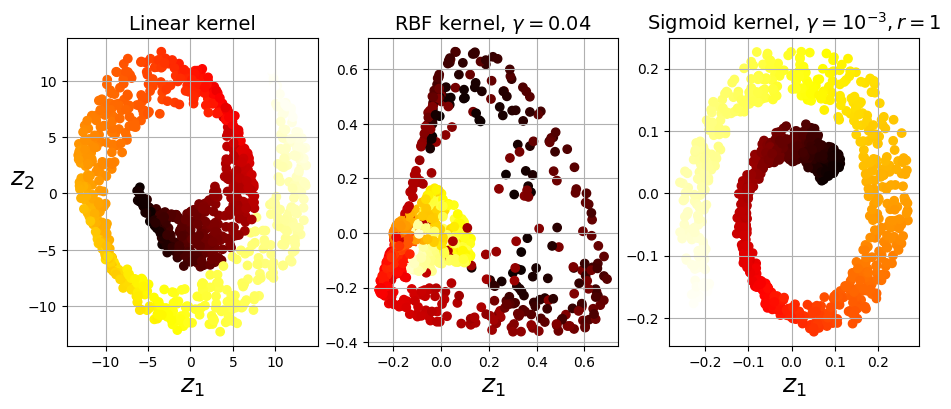

In [3]:
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt

lin_pca = KernelPCA(n_components = 2, kernel="linear", fit_inverse_transform=True)
rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.0433, fit_inverse_transform=True)
sig_pca = KernelPCA(n_components = 2, kernel="sigmoid", gamma=0.001, coef0=1, fit_inverse_transform=True)

y = t > 6.9

plt.figure(figsize=(11, 4))
for subplot, pca, title in ((131, lin_pca, "Linear kernel"), (132, rbf_pca, "RBF kernel, $\gamma=0.04$"), (133, sig_pca, "Sigmoid kernel, $\gamma=10^{-3}, r=1$")):
    X_reduced = pca.fit_transform(X)
    if subplot == 132:
        X_reduced_rbf = X_reduced

    plt.subplot(subplot)
    #plt.plot(X_reduced[y, 0], X_reduced[y, 1], "gs")
    #plt.plot(X_reduced[~y, 0], X_reduced[~y, 1], "y^")
    plt.title(title, fontsize=14)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
    plt.xlabel("$z_1$", fontsize=18)
    if subplot == 131:
        plt.ylabel("$z_2$", fontsize=18, rotation=0)
    plt.grid(True)

plt.show()

# As you can see above, we have used 3 versions of Kernel PCA to change the way data looks like. You can use different kernel in read data to decide what you want to do with your data and which Kernel you want to use

# Lets create a logistic model and use Kernel PCA as hyper parameter to test the performance of model

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

clf = Pipeline([
        ("kpca", KernelPCA(n_components=2)),
        ("log_reg", LogisticRegression(solver="liblinear"))
    ])

param_grid = [{
        "kpca__gamma": np.linspace(0.03, 0.05, 10),
        "kpca__kernel": ["rbf", "sigmoid"]
    }]

grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kpca', KernelPCA(n_components=2)),
                                       ('log_reg',
                                        LogisticRegression(solver='liblinear'))]),
             param_grid=[{'kpca__gamma': array([0.03      , 0.03222222, 0.03444444, 0.03666667, 0.03888889,
       0.04111111, 0.04333333, 0.04555556, 0.04777778, 0.05      ]),
                          'kpca__kernel': ['rbf', 'sigmoid']}])

In [ ]:
print(grid_search.best_params_)

{'kpca__gamma': 0.043333333333333335, 'kpca__kernel': 'rbf'}


# Use above optimized hyper parameter to build a better model

*   List item
*   List item



In [5]:
rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.0433,
                    fit_inverse_transform=True)
X_reduced = rbf_pca.fit_transform(X)
X_preimage = rbf_pca.inverse_transform(X_reduced)

# Your code to train a new model


# What is the performance of the model?

In [6]:
# Your code to evaluate

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train model on transformed data
model = LogisticRegression()
model.fit(X_reduced, y)

# Predict
y_pred = model.predict(X_reduced)

# Accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

# Detailed report
print("\nClassification Report:")
print(classification_report(y, y_pred))

Accuracy: 0.952

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.81      0.89       249
        True       0.94      1.00      0.97       751

    accuracy                           0.95      1000
   macro avg       0.97      0.90      0.93      1000
weighted avg       0.95      0.95      0.95      1000



In [7]:
# Compare with original data
model_orig = LogisticRegression()
model_orig.fit(X, y)
y_pred_orig = model_orig.predict(X)

print("Original Accuracy:", accuracy_score(y, y_pred_orig))
print("KPCA Accuracy:", accuracy_score(y, y_pred))

Original Accuracy: 0.711
KPCA Accuracy: 0.952


# In order to gain better understanding, you can build a model on original dataset and compare MSE to see what is the impact of KPCA

In [8]:
#This is a basic model using original data
lr = LogisticRegression(solver="liblinear")
lr.fit(X, y)

LogisticRegression(solver='liblinear')

In [9]:
from sklearn.metrics import mean_squared_error
y_hat = lr.predict(X)

#Evaluate your base model and compare this with the one with KPCA